In [314]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)
SAVE_DPI = 300

plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 110,
        "savefig.dpi": SAVE_DPI,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.axisbelow": True,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
    }
)

HBI_COLOR = "#3b82f6"
NN_COLOR = "#f97316"
CORRECT_COLOR = "#10b981"
INCORRECT_COLOR = "#ef4444"
NEUTRAL_COLOR = "#6b7280"


def save_plot(fig, filename: str) -> Path:
    path = PLOTS_DIR / filename
    fig.savefig(path, dpi=SAVE_DPI, bbox_inches="tight")
    return path


def _annotate_bars(ax, bars, values, fmt="{:.2f}", errors=None, offset=0.02, fontsize=9):
    for i, (bar, v) in enumerate(zip(bars, values)):
        if errors is not None and i < len(errors) and errors[i] is not None:
            label = f"{fmt.format(v)} ±{errors[i]:.3f}"
        else:
            label = fmt.format(v)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            label,
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )


def plot_confidence_bins(ax, confidences, correct, title):
    """Side-by-side correct vs incorrect counts for 0.1-wide confidence bins."""
    bin_edges = np.linspace(0.0, 1.0, 11)
    bin_labels = [
        f"{lo:.1f}–{hi:.1f}"
        for lo, hi in zip(bin_edges[:-1], bin_edges[1:])
    ]
    correct_counts, incorrect_counts = [], []

    for i, (lo, hi) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        if i == len(bin_edges) - 2:
            mask = (confidences >= lo) & (confidences <= hi)
        else:
            mask = (confidences >= lo) & (confidences < hi)
        correct_counts.append(int(correct[mask].sum()))
        incorrect_counts.append(int((~correct)[mask].sum()))

    x = np.arange(len(bin_labels))
    bar_w = 0.36
    ax.bar(
        x - bar_w / 2,
        correct_counts,
        bar_w,
        label="Correct",
        color=CORRECT_COLOR,
        edgecolor="white",
    )
    ax.bar(
        x + bar_w / 2,
        incorrect_counts,
        bar_w,
        label="Incorrect",
        color=INCORRECT_COLOR,
        edgecolor="white",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=45, ha="right")
    ax.set_title(title)
    ax.set_xlabel("Confidence bin")
    ax.set_ylabel("Count")
    ax.set_yscale("log")
    ax.legend()

## Test Set

### HBI

In [315]:
hbi_test = pd.read_csv("../benchmark/test_set/hbi/predictions.csv")
print(len(hbi_test))
hbi_test.head()

9779


,identifier,actual_label,predicted_label,confidence
0,P01502,other,other,0.908
1,A6YPK1,CRISP family,CRISP family,0.515
2,Q7ZTA0,CRISP family,CRISP family,0.894
3,Q8JI38,CRISP family,CRISP family,0.947
4,A6MFK9,CRISP family,CRISP family,0.866


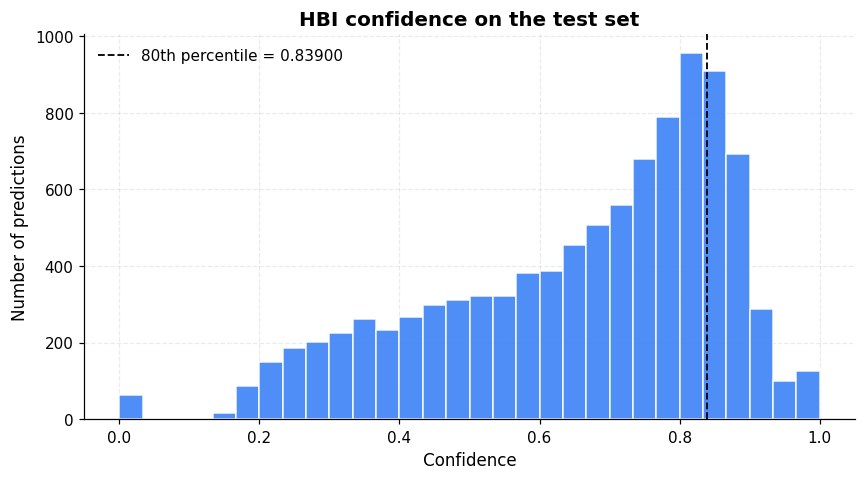

In [316]:
fig, ax = plt.subplots()
ax.hist(hbi_test["confidence"], bins=30, color=HBI_COLOR, edgecolor="white", alpha=0.9)
q80 = hbi_test["confidence"].quantile(0.8)
ax.axvline(q80, color="black", linestyle="--", linewidth=1.2, label=f"80th percentile = {q80:.5f}")
ax.set_title("HBI confidence on the test set")
ax.set_xlabel("Confidence")
ax.set_ylabel("Number of predictions")
ax.legend()
plt.tight_layout()
save_plot(fig, "test_set_hbi_confidence_histogram.png")
plt.show()

In [317]:
hbi_test["confidence"].quantile(0.8)

np.float64(0.839)

In [318]:
hbi_test[hbi_test["confidence"] < 0.8]

,identifier,actual_label,predicted_label,confidence
1,A6YPK1,CRISP family,CRISP family,0.515
7,P86802,Venom metalloproteinase (M12B) family,Venom metalloproteinase (M12B) family,0.739
8,Q14FJ4,Venom metalloproteinase (M12B) family,Venom metalloproteinase (M12B) family,0.767
10,Q90495,Venom metalloproteinase (M12B) family,Venom metalloproteinase (M12B) family,0.764
12,A8QL59,Venom metalloproteinase (M12B) family,Venom metalloproteinase (M12B) family,0.660
...,...,...,...,...
9769,P0CD69,MCD family,MCD family,0.785
9771,P0DN49,Teretoxin family,Teretoxin family,0.647
9772,P0DN58,Teretoxin family,Teretoxin family,0.674
9774,P0CI44,Long (3 C-C) scorpion toxin superfamily,Long (3 C-C) scorpion toxin superfamily,0.757


In [319]:
hbi_test[hbi_test["actual_label"] != hbi_test["predicted_label"]]

,identifier,actual_label,predicted_label,confidence
19,B5AJT3,Venom metalloproteinase (M12B) family,nontox,0.294
25,Q805F5,Disintegrin family,Venom metalloproteinase (M12B) family,0.958
31,P0DQG1,Scoloptoxin family,nontox,0.343
42,P0DPY2,Scoloptoxin family,nontox,0.334
49,P0DJK6,"Natriuretic, Bradykinin potentiating peptide f...",nontox,0.743
...,...,...,...,...
9755,P0DX60,Formicidae venom family,nontox,0.565
9760,P86147,MCD family,nontox,0.537
9764,P0C1R1,MCD family,nontox,0.791
9767,P17237,MCD family,nontox,0.942


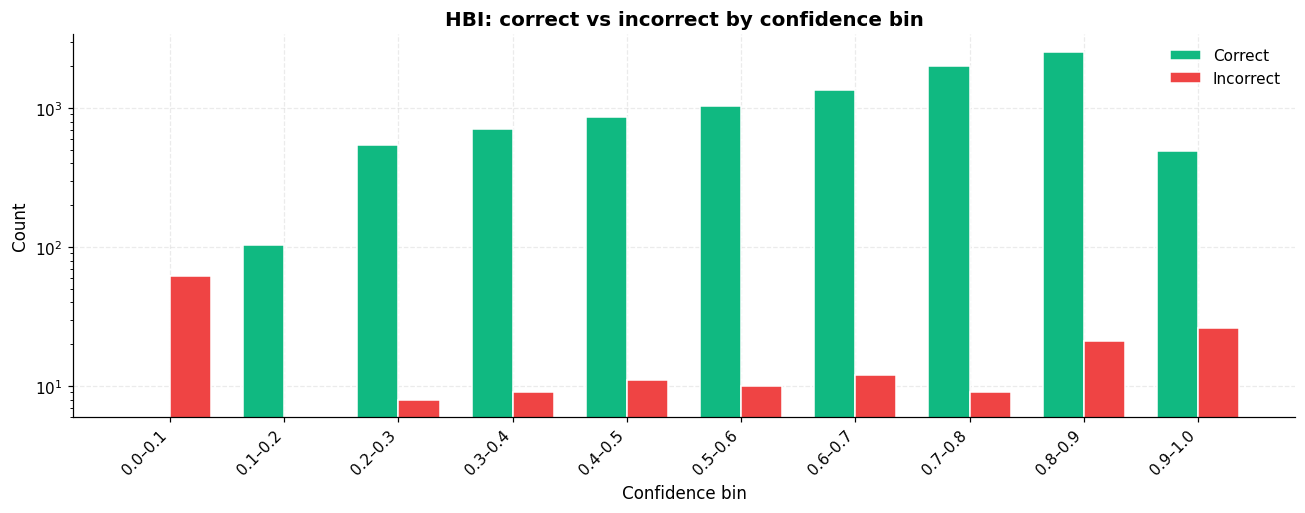

80th-percentile confidence of misclassifications: 0.861


In [320]:
hbi_correct = hbi_test["actual_label"] == hbi_test["predicted_label"]
hbi_wrong_conf = hbi_test.loc[~hbi_correct, "confidence"]

fig, ax = plt.subplots(figsize=(12, 4.8))
plot_confidence_bins(
    ax,
    hbi_test["confidence"],
    hbi_correct.to_numpy(),
    "HBI: correct vs incorrect by confidence bin",
)
plt.tight_layout()
save_plot(fig, "test_set_hbi_correct_vs_incorrect_confidence_bins.png")
plt.show()

print(f"80th-percentile confidence of misclassifications: {hbi_wrong_conf.quantile(0.8):.3f}")

### Model

In [321]:
model_test = pd.read_csv("../benchmark/test_set/nn_combined_run/predictions.csv")
if "confidence_uncalibrated" not in model_test.columns:
    print(
        "Missing confidence_uncalibrated — re-run: "
        "uv run toxfam eval model test_set --model-dir model/model_output/combined_run"
    )
print(len(model_test))
model_test.head()

9779


,identifier,actual_label,predicted_label,confidence,confidence_uncalibrated
0,P01502,other,other,0.990660,0.999581
1,A6YPK1,CRISP family,CRISP family,0.927131,0.984318
2,Q7ZTA0,CRISP family,CRISP family,0.999888,1.000000
3,Q8JI38,CRISP family,CRISP family,0.999870,1.000000
4,A6MFK9,CRISP family,CRISP family,0.999845,1.000000


In [322]:
len(model_test)

9779

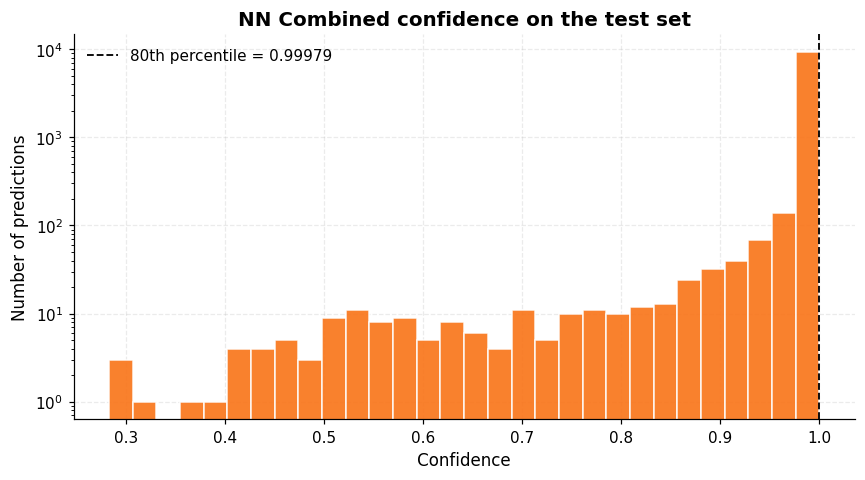

In [323]:
fig, ax = plt.subplots()
ax.hist(model_test["confidence"], bins=30, color=NN_COLOR, edgecolor="white", alpha=0.9)
q80 = model_test["confidence"].quantile(0.8)
ax.axvline(q80, color="black", linestyle="--", linewidth=1.2, label=f"80th percentile = {q80:.5f}")
ax.set_title("NN Combined confidence on the test set")
ax.set_xlabel("Confidence")
ax.set_yscale("log")
ax.set_ylabel("Number of predictions")
ax.legend()
plt.tight_layout()
save_plot(fig, "test_set_nn_confidence_histogram.png")
plt.show()

In [324]:
model_test["confidence"].quantile(0.8)

np.float64(0.9997949481010437)

In [325]:
model_test[model_test["confidence"] > 0.8]

,identifier,actual_label,predicted_label,confidence,confidence_uncalibrated
0,P01502,other,other,0.990660,0.999581
1,A6YPK1,CRISP family,CRISP family,0.927131,0.984318
2,Q7ZTA0,CRISP family,CRISP family,0.999888,1.000000
3,Q8JI38,CRISP family,CRISP family,0.999870,1.000000
4,A6MFK9,CRISP family,CRISP family,0.999845,1.000000
...,...,...,...,...,...
9774,P0CI44,Long (3 C-C) scorpion toxin superfamily,Long (3 C-C) scorpion toxin superfamily,0.999618,0.999996
9775,P0C297,Long (3 C-C) scorpion toxin superfamily,Long (3 C-C) scorpion toxin superfamily,0.975125,0.997009
9776,P0C299,Long (3 C-C) scorpion toxin superfamily,Long (3 C-C) scorpion toxin superfamily,0.999959,1.000000
9777,Q4LCT2,Long (3 C-C) scorpion toxin superfamily,Long (3 C-C) scorpion toxin superfamily,0.999969,1.000000


In [326]:
model_false = model_test[model_test["actual_label"] != model_test["predicted_label"]]
model_false.head()

,identifier,actual_label,predicted_label,confidence,confidence_uncalibrated
102,A0A6P3CW73,nontox,Short scorpion toxin superfamily,0.999987,1.000000
144,A3FMN3,nontox,other,0.506889,0.607074
805,P17534,nontox,Conotoxin family,0.541035,0.600580
975,P31398,nontox,other,0.903763,0.978028
996,P34179,nontox,Venom metalloproteinase (M12B) family,0.999724,0.999999


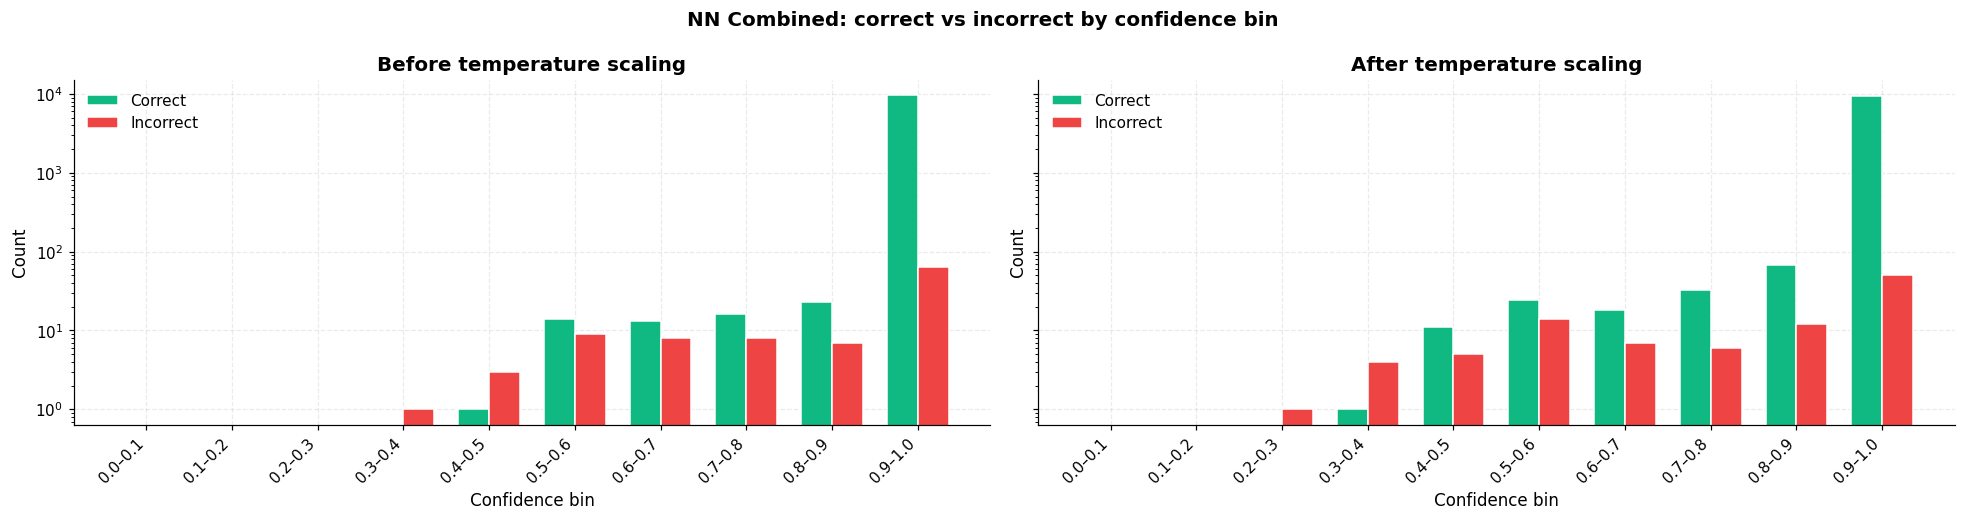

80th-percentile confidence of misclassifications: 0.993


In [327]:
nn_correct = model_test["actual_label"] == model_test["predicted_label"]
nn_wrong_conf = model_test.loc[~nn_correct, "confidence"]

if "confidence_uncalibrated" in model_test.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 4.8), sharey=True)
    plot_confidence_bins(
        axes[0],
        model_test["confidence_uncalibrated"],
        nn_correct.to_numpy(),
        "Before temperature scaling",
    )
    plot_confidence_bins(
        axes[1],
        model_test["confidence"],
        nn_correct.to_numpy(),
        "After temperature scaling",
    )
    fig.suptitle(
        "NN Combined: correct vs incorrect by confidence bin",
        fontsize=13,
        fontweight="bold",
    )
else:
    fig, ax = plt.subplots(figsize=(12, 4.8))

    plot_confidence_bins(
        ax,
        model_test["confidence"],
        nn_correct.to_numpy(),
        "NN Combined: after temperature scaling (re-run eval for before scaling)",
    )

plt.tight_layout()
save_plot(
    fig,
    "test_set_nn_correct_vs_incorrect_confidence_bins_before_after_scaling.png"
    if "confidence_uncalibrated" in model_test.columns
    else "test_set_nn_correct_vs_incorrect_confidence_bins_after_scaling.png",
)
plt.show()

print(f"80th-percentile confidence of misclassifications: {nn_wrong_conf.quantile(0.8):.3f}")

In [328]:
model_test.iloc[nn_wrong_conf[nn_wrong_conf >= 0.8].index] #.to_csv("model_test_wrong_conf.csv", index=False) # everything above 0.8 confidence and wrongly predicted on calibrated confidences

,identifier,actual_label,predicted_label,confidence,confidence_uncalibrated
102,A0A6P3CW73,nontox,Short scorpion toxin superfamily,0.999987,1.000000
975,P31398,nontox,other,0.903763,0.978028
996,P34179,nontox,Venom metalloproteinase (M12B) family,0.999724,0.999999
1771,Q4VRI5,nontox,Phospholipase family,0.990309,0.999372
2747,O42190,nontox,Phospholipase family,0.993463,0.999655
...,...,...,...,...,...
9552,P0DUS3,Limacoditoxin family,FARP (FMRFamide related peptide) family,0.898675,0.982478
9686,P83055,Bradykinin-related peptide family,nontox,0.891971,0.988645
9760,P86147,MCD family,Formicidae venom family,0.971315,0.997737
9770,P0DN47,Teretoxin family,Conotoxin family,0.998568,0.999985


In [329]:
model_false[model_false["confidence"] > 0.8]

,identifier,actual_label,predicted_label,confidence,confidence_uncalibrated
102,A0A6P3CW73,nontox,Short scorpion toxin superfamily,0.999987,1.000000
975,P31398,nontox,other,0.903763,0.978028
996,P34179,nontox,Venom metalloproteinase (M12B) family,0.999724,0.999999
1771,Q4VRI5,nontox,Phospholipase family,0.990309,0.999372
2747,O42190,nontox,Phospholipase family,0.993463,0.999655
...,...,...,...,...,...
9552,P0DUS3,Limacoditoxin family,FARP (FMRFamide related peptide) family,0.898675,0.982478
9686,P83055,Bradykinin-related peptide family,nontox,0.891971,0.988645
9760,P86147,MCD family,Formicidae venom family,0.971315,0.997737
9770,P0DN47,Teretoxin family,Conotoxin family,0.998568,0.999985


In [330]:
model_false[model_false["actual_label"] == "nontox"].sort_values(by="confidence", ascending=False)

,identifier,actual_label,predicted_label,confidence,confidence_uncalibrated
102,A0A6P3CW73,nontox,Short scorpion toxin superfamily,0.999987,1.000000
9235,Q9W716,nontox,Three-finger toxin family,0.999973,1.000000
5436,P0DQU7,nontox,Long (4 C-C) scorpion toxin superfamily,0.999950,1.000000
7937,P0DPL1,nontox,Conotoxin family,0.999762,0.999999
996,P34179,nontox,Venom metalloproteinase (M12B) family,0.999724,0.999999
...,...,...,...,...,...
8165,P82660,nontox,FARP (FMRFamide related peptide) family,0.420859,0.503464
7830,M1E1F0,nontox,Scoloptoxin family,0.370581,0.510811
6809,Q8MVA6,nontox,Neurotoxin family,0.328510,0.509303
6177,Q7M463,nontox,Short scorpion toxin superfamily,0.303585,0.392087


## Unreviewed
(keyword:KW-0800) AND (reviewed:false) AND (taxonomy_id:33208) AND (fragment:false)

Unreviewed predictions: 15199


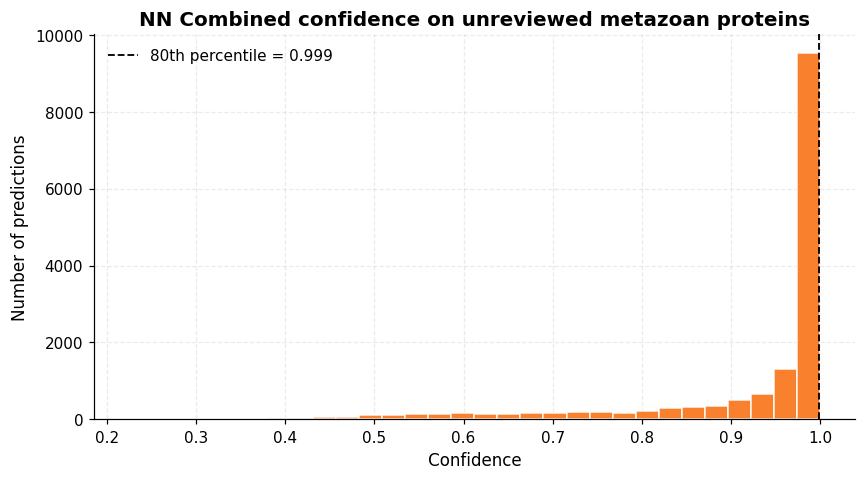

,identifier,actual_label,predicted_label,confidence
13,A0A6J1TTB3,Nucleotide pyrophosphatase/phosphodiesterase f...,other,0.791376
17,A0A6P9BXA6,Nucleotide pyrophosphatase/phosphodiesterase f...,other,0.760243
22,A0A803T3F9,Nucleotide pyrophosphatase/phosphodiesterase f...,other,0.784737
26,A0A8C6V2H9,Nucleotide pyrophosphatase/phosphodiesterase f...,other,0.750246
31,A0A8C6Y5N2,Venom metalloproteinase (M12B) family,nontox,0.724093
...,...,...,...,...
15187,X5IGX0,Conotoxin family,Conotoxin family,0.503697
15190,X5IWM7,Conotoxin family,Conotoxin family,0.531405
15192,X5IWP4,Conotoxin family,nontox,0.473164
15193,X5IWP6,Conotoxin family,nontox,0.506718


In [331]:
model_unreviewed = pd.read_csv("../benchmark/unreviewed/nn_combined_run/predictions.csv")
print(f"Unreviewed predictions: {len(model_unreviewed)}")

fig, ax = plt.subplots()
ax.hist(model_unreviewed["confidence"], bins=30, color=NN_COLOR, edgecolor="white", alpha=0.9)
q80 = model_unreviewed["confidence"].quantile(0.8)
ax.axvline(q80, color="black", linestyle="--", linewidth=1.2, label=f"80th percentile = {q80:.3f}")
ax.set_title("NN Combined confidence on unreviewed metazoan proteins")
ax.set_xlabel("Confidence")
ax.set_ylabel("Number of predictions")
ax.legend()
plt.tight_layout()
save_plot(fig, "unreviewed_nn_confidence_histogram.png")
plt.show()

model_unreviewed[model_unreviewed["confidence"] < 0.8]

In [332]:
classes = pd.read_json("../model/model_output/combined_run/class_indices.json", typ="series")
classes

0                                    Actinoporin family
1                     Bradykinin-related peptide family
2                                          CRISP family
3                                   Calycin superfamily
4                               Cationic peptide family
5     Cnidaria small cysteine-rich protein (SCRiP) f...
6                                      Conotoxin family
7                                    Disintegrin family
8               FARP (FMRFamide related peptide) family
9                       Flavin monoamine oxidase family
10                              Formicidae venom family
11                                       Insulin family
12                                 Limacoditoxin family
13              Long (3 C-C) scorpion toxin superfamily
14              Long (4 C-C) scorpion toxin superfamily
15                     Long chain scorpion toxin family
16                                           MCD family
17    Natriuretic, Bradykinin potentiating pepti

In [333]:
model_unreviewed["label_group"] = "other"

# Update only the rows where the label is found in classes
is_valid = model_unreviewed["actual_label"].isin(classes.values)
model_unreviewed.loc[is_valid, "label_group"] = model_unreviewed["actual_label"]

In [334]:
model_unreviewed[model_unreviewed["label_group"] != model_unreviewed["predicted_label"]] # with actual_label col, there is like 9k rows instead

,identifier,actual_label,predicted_label,confidence,label_group
0,A0A147BNI3,NOTCH family,nontox,0.997856,other
1,A0A4Y2G8R1,NOTCH family,nontox,0.998894,other
2,A0A670IWD1,Endothelin/sarafotoxin family,nontox,0.959038,other
8,A0A670XY21,Endothelin/sarafotoxin family,nontox,0.976825,other
11,A0A670YZZ1,Flavin monoamine oxidase family,nontox,0.993792,Flavin monoamine oxidase family
...,...,...,...,...,...
15185,X5IG01,Conotoxin family,nontox,0.657876,Conotoxin family
15186,X5IG04,Conotoxin family,nontox,0.851222,Conotoxin family
15192,X5IWP4,Conotoxin family,nontox,0.473164,Conotoxin family
15193,X5IWP6,Conotoxin family,nontox,0.506718,Conotoxin family


## Non-Metazoa

Non-metazoan predictions: 702


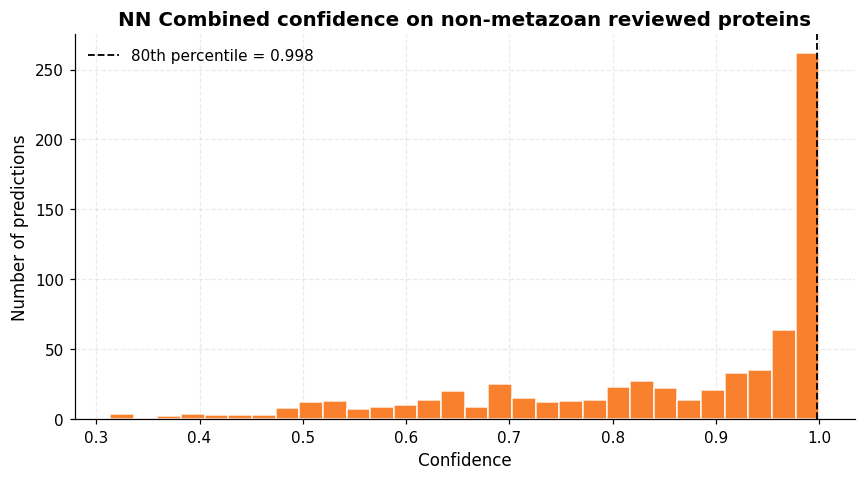

,identifier,actual_label,predicted_label,confidence
0,A0A0H2US87,other,nontox,0.988127
1,A0A0H3AIG7,other,nontox,0.881134
2,A0A0H3NK84,Glycosyltransferase NleB family,nontox,0.998652
3,A0A1S4NYE3,CdiA toxin family,nontox,0.971726
4,A0A218N034,WTF family,nontox,0.999990


In [335]:
model_nonmetazoa = pd.read_csv("../benchmark/non_metazoan/nn_combined_run/predictions.csv")
print(f"Non-metazoan predictions: {len(model_nonmetazoa)}")

fig, ax = plt.subplots()
ax.hist(model_nonmetazoa["confidence"], bins=30, color=NN_COLOR, edgecolor="white", alpha=0.9)
q80 = model_nonmetazoa["confidence"].quantile(0.8)
ax.axvline(q80, color="black", linestyle="--", linewidth=1.2, label=f"80th percentile = {q80:.3f}")
ax.set_title("NN Combined confidence on non-metazoan reviewed proteins")
ax.set_xlabel("Confidence")
ax.set_ylabel("Number of predictions")
ax.legend()
plt.tight_layout()
save_plot(fig, "non_metazoan_nn_confidence_histogram.png")
plt.show()

model_nonmetazoa.head()

In [336]:
model_nonmetazoa[model_nonmetazoa["predicted_label"] != "nontox"]

,identifier,actual_label,predicted_label,confidence
34,P09167,Aerolysin family,other,0.586554
37,P09616,Aerolysin family,other,0.674939
44,P0C2E9,Cholesterol-dependent cytolysin family,other,0.839097
59,P13128,Cholesterol-dependent cytolysin family,other,0.761472
86,Q04IN8,Cholesterol-dependent cytolysin family,other,0.970290
...,...,...,...,...
689,U5L397,MSDIN fungal toxin family,Conotoxin family,0.857487
691,U5L3J7,MSDIN fungal toxin family,Conotoxin family,0.863098
695,U5L3M7,MSDIN fungal toxin family,Conotoxin family,0.601714
700,U5L408,MSDIN fungal toxin family,Conotoxin family,0.517371


In [337]:
model_nonmetazoa[model_nonmetazoa["confidence"] > 0.9]["predicted_label"].value_counts()

predicted_label
nontox                              379
other                                12
Conotoxin family                      4
Neurotoxin family                     2
Short scorpion toxin superfamily      1
Actinoporin family                    1
Name: count, dtype: int64

In [338]:
model_nonmetazoa["predicted_label"].value_counts()

predicted_label
nontox                                                 573
other                                                   91
Conotoxin family                                        24
Neurotoxin family                                        5
Limacoditoxin family                                     3
Short scorpion toxin superfamily                         2
Formicidae venom family                                  2
Cnidaria small cysteine-rich protein (SCRiP) family      1
Actinoporin family                                       1
Name: count, dtype: int64

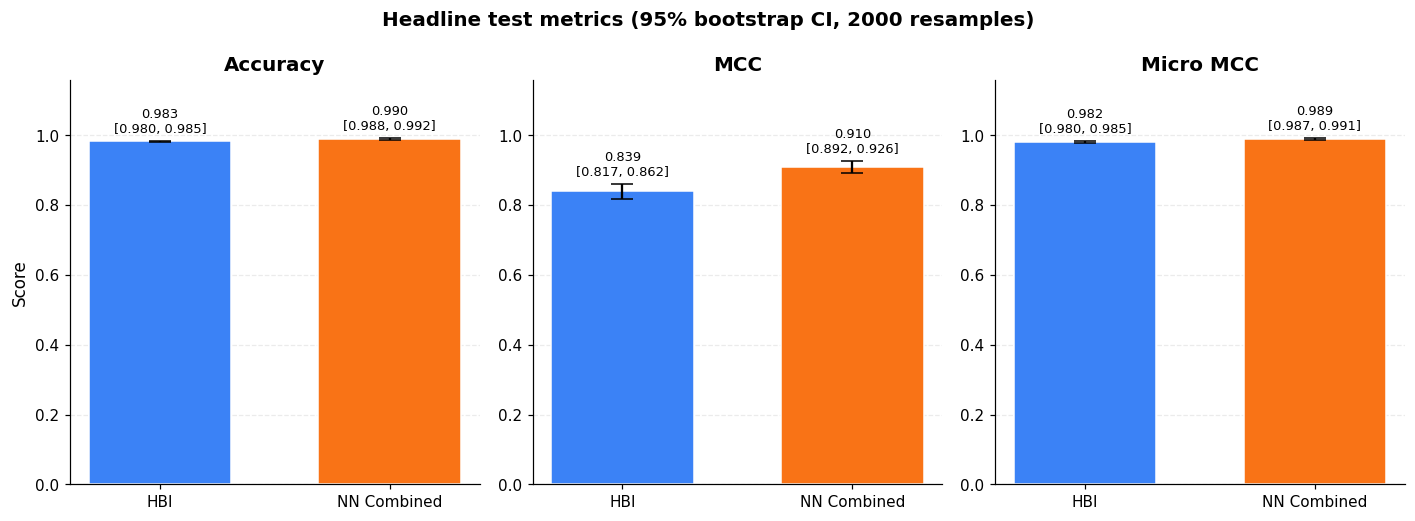

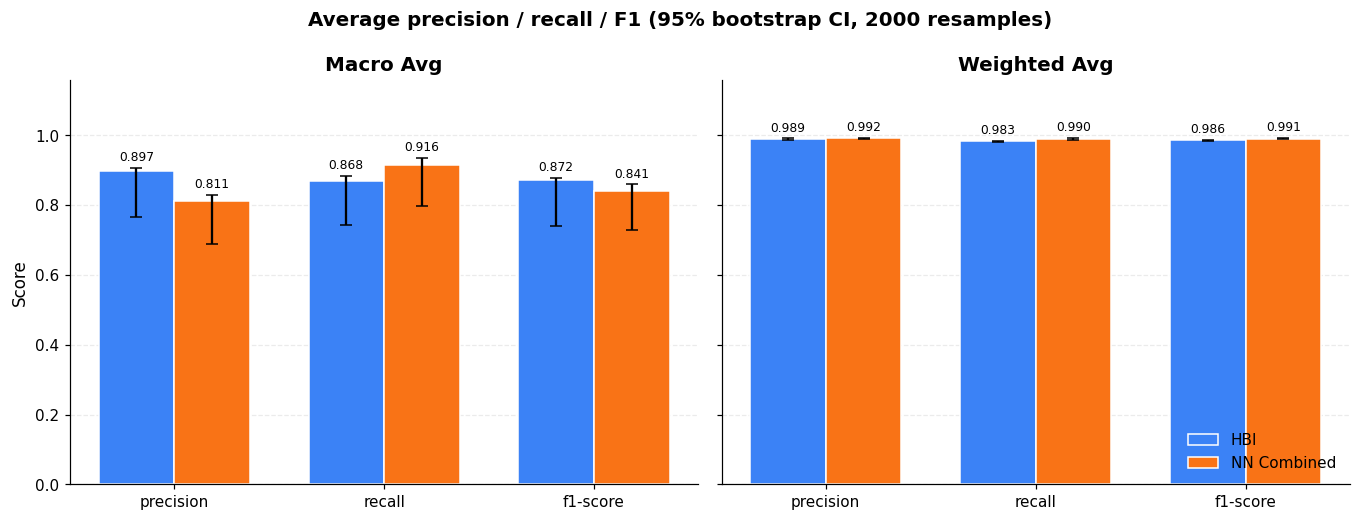

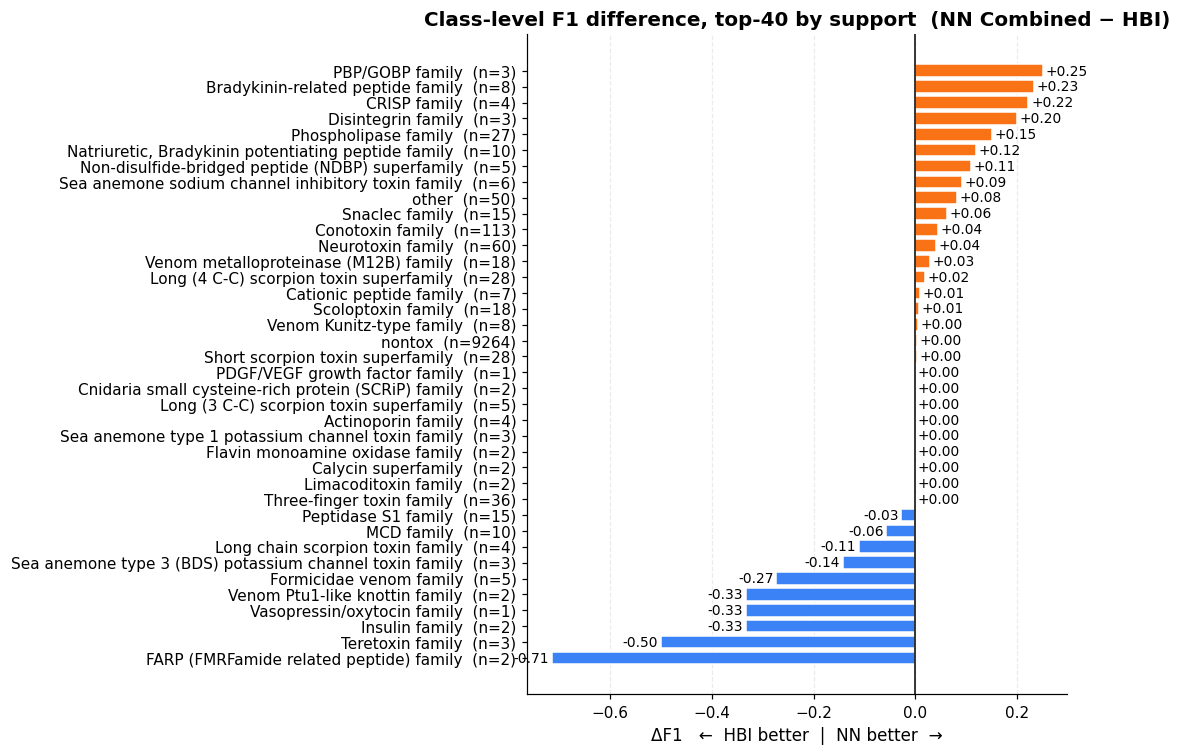

,method,metric,value,ci_low,ci_high
0,HBI,Accuracy,0.982820,0.980264,0.985377
1,HBI,MCC,0.839368,0.816680,0.861776
2,HBI,Micro_MCC,0.982368,0.979744,0.984992
3,HBI,macro precision,0.896800,0.766805,0.907147
4,HBI,macro recall,0.868203,0.743251,0.882752
5,HBI,macro f1-score,0.871706,0.740996,0.878308
6,HBI,weighted precision,0.989220,0.987340,0.991465
7,HBI,weighted recall,0.982820,0.980264,0.985377
8,HBI,weighted f1-score,0.985689,0.983479,0.987938
9,NN Combined,Accuracy,0.989774,0.987627,0.991717


In [339]:
import json
from pathlib import Path

hbi_metrics_path = Path("../benchmark/test_set/hbi/metrics.json")
nn_metrics_path = Path("../benchmark/test_set/nn_combined_run/metrics.json")

with hbi_metrics_path.open() as f:
    hbi_metrics = json.load(f)
with nn_metrics_path.open() as f:
    nn_metrics = json.load(f)

models = {"HBI": hbi_metrics, "NN Combined": nn_metrics}
model_colors = {"HBI": HBI_COLOR, "NN Combined": NN_COLOR}
width = 0.36

# ---------------------------------------------------------------------------
# Bootstrap 95% confidence intervals.
# No inference needed — we only resample the existing (actual, predicted)
# label pairs in predictions.csv and recompute every metric. Metrics are
# computed in closed form from confusion counts so 2000 resamples is instant.
# Macro/weighted P-R-F1 are restricted to the canonical 38-class list (matches
# metrics.json and ignores the HBI "no hit" non-prediction); accuracy / MCC /
# micro-MCC count "no hit" as simply wrong, exactly as the stored metrics do.
# ---------------------------------------------------------------------------
CLASS_LIST = pd.read_json(
    "../model/model_output/combined_run/class_indices.json", typ="series"
).tolist()
N_CLASS = len(CLASS_LIST)
N_BOOT = 2000
boot_rng = np.random.default_rng(0)

pred_paths = {
    "HBI": "../benchmark/test_set/hbi/predictions.csv",
    "NN Combined": "../benchmark/test_set/nn_combined_run/predictions.csv",
}


def _suite(true_canon, pred_canon, true_union, pred_union, n_union_classes):
    """All scalar metrics from label arrays, via confusion counts only.

    *_canon are indices into the canonical 38-class list (-1 if outside it);
    *_union are indices into the union of labels actually present (used for the
    label-set-invariant accuracy / MCC / micro-MCC).
    """
    n = len(true_union)
    correct = float((true_union == pred_union).sum())
    acc = correct / n

    # Multiclass MCC (Gorodkin) over the union label set.
    t_k = np.bincount(true_union, minlength=n_union_classes).astype(float)
    p_k = np.bincount(pred_union, minlength=n_union_classes).astype(float)
    s = float(n)
    mcc_den = np.sqrt((s * s - (p_k**2).sum()) * (s * s - (t_k**2).sum()))
    mcc = (correct * s - (t_k * p_k).sum()) / mcc_den if mcc_den > 0 else 0.0

    # Micro-MCC: MCC of the one-vs-all one-hot matrices. Each sample has exactly
    # one true and one predicted "1", so TP=#correct, FP=FN=#wrong (closed form).
    wrong = n - correct
    tp, fp, fn = correct, wrong, wrong
    tn = s * n_union_classes - correct - 2 * wrong
    micro_den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    micro_mcc = (tp * tn - fp * fn) / micro_den if micro_den > 0 else 0.0

    # Precision / recall / F1 per canonical class, then macro & support-weighted.
    valid_t = true_canon >= 0
    valid_p = pred_canon >= 0
    hit = (true_canon == pred_canon) & valid_t
    tp_c = np.bincount(true_canon[hit], minlength=N_CLASS).astype(float)
    pred_c = np.bincount(pred_canon[valid_p], minlength=N_CLASS).astype(float)
    true_c = np.bincount(true_canon[valid_t], minlength=N_CLASS).astype(float)
    with np.errstate(invalid="ignore", divide="ignore"):
        prec = np.where(pred_c > 0, tp_c / pred_c, 0.0)
        rec = np.where(true_c > 0, tp_c / true_c, 0.0)
        f1 = np.where((pred_c + true_c) > 0, 2 * tp_c / (pred_c + true_c), 0.0)
    support = true_c.sum()

    return {
        "Accuracy": acc,
        "MCC": mcc,
        "Micro_MCC": micro_mcc,
        "macro precision": prec.mean(),
        "macro recall": rec.mean(),
        "macro f1-score": f1.mean(),
        "weighted precision": (prec * true_c).sum() / support,
        "weighted recall": (rec * true_c).sum() / support,
        "weighted f1-score": (f1 * true_c).sum() / support,
    }


def bootstrap_cis(pred_csv: str, n_boot: int = N_BOOT) -> dict:
    df = pd.read_csv(pred_csv)
    y_true = df["actual_label"].to_numpy()
    y_pred = df["predicted_label"].to_numpy()

    union = sorted(set(y_true) | set(y_pred))
    u_idx = {lab: i for i, lab in enumerate(union)}
    c_idx = {lab: i for i, lab in enumerate(CLASS_LIST)}
    k_union = len(union)

    true_union = np.array([u_idx[x] for x in y_true])
    pred_union = np.array([u_idx[x] for x in y_pred])
    true_canon = np.array([c_idx.get(x, -1) for x in y_true])
    pred_canon = np.array([c_idx.get(x, -1) for x in y_pred])

    point = _suite(true_canon, pred_canon, true_union, pred_union, k_union)
    draws = {k: np.empty(n_boot) for k in point}
    n = len(y_true)
    for b in range(n_boot):
        idx = boot_rng.integers(0, n, n)
        m = _suite(
            true_canon[idx], pred_canon[idx], true_union[idx], pred_union[idx], k_union
        )
        for k, v in m.items():
            draws[k][b] = v

    return {k: (point[k], *np.percentile(draws[k], [2.5, 97.5])) for k in point}


ci = {name: bootstrap_cis(path) for name, path in pred_paths.items()}

# -------- 1) Headline numeric metrics — one panel per metric --------
headline_metrics = ["Accuracy", "MCC", "Micro_MCC"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
for ax, metric in zip(axes, headline_metrics):
    names = list(models)
    xs = np.arange(len(names))
    for j, name in enumerate(names):
        point, lo, hi = ci[name][metric]
        ax.bar(
            j,
            point,
            0.62,
            yerr=[[point - lo], [hi - point]],
            capsize=7,
            color=model_colors[name],
            edgecolor="white",
        )
        ax.text(
            j,
            hi + 0.015,
            f"{point:.3f}\n[{lo:.3f}, {hi:.3f}]",
            ha="center",
            va="bottom",
            fontsize=8.5,
        )
    ax.set_title(metric.replace("_", " "))
    ax.set_xticks(xs)
    ax.set_xticklabels(names)
    ax.set_ylim(0, 1.16)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Score")
fig.suptitle(
    f"Headline test metrics (95% bootstrap CI, {N_BOOT} resamples)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
save_plot(fig, "test_set_headline_metrics.png")
plt.show()

# -------- 2) Macro / weighted P-R-F1 comparison --------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
for ax, avg_name in zip(axes, ["macro", "weighted"]):
    metric_names = ["precision", "recall", "f1-score"]
    x_sub = np.arange(len(metric_names))
    for i, name in enumerate(models):
        offset = (i - 0.5) * width
        points, yerr_lo, yerr_hi = [], [], []
        for mt in metric_names:
            p, lo, hi = ci[name][f"{avg_name} {mt}"]
            points.append(p)
            yerr_lo.append(p - lo)
            yerr_hi.append(hi - p)
        ax.bar(
            x_sub + offset,
            points,
            width,
            yerr=[yerr_lo, yerr_hi],
            capsize=4,
            label=name,
            color=model_colors[name],
            edgecolor="white",
        )
        for k, mt in enumerate(metric_names):
            p, lo, hi = ci[name][f"{avg_name} {mt}"]
            ax.text(
                x_sub[k] + offset, hi + 0.012, f"{p:.3f}", ha="center", va="bottom", fontsize=8
            )
    ax.set_title(f"{avg_name} avg".title())
    ax.set_xticks(x_sub)
    ax.set_xticklabels(metric_names)
    ax.set_ylim(0, 1.16)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Score")
axes[1].legend(loc="lower right")
fig.suptitle(
    f"Average precision / recall / F1 (95% bootstrap CI, {N_BOOT} resamples)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
save_plot(fig, "test_set_avg_precision_recall_f1.png")
plt.show()

# -------- 3) Class-level F1 differences (NN - HBI), top-support classes --------
ignore_labels = {"accuracy", "macro avg", "weighted avg", "micro avg"}
common_labels = sorted(
    set(hbi_metrics["classification_report"].keys())
    & set(nn_metrics["classification_report"].keys())
    - ignore_labels
)

class_rows = []
for label in common_labels:
    hbi_row = hbi_metrics["classification_report"][label]
    nn_row = nn_metrics["classification_report"][label]
    if isinstance(hbi_row, dict) and isinstance(nn_row, dict):
        class_rows.append({
            "label": label, "support": int(hbi_row["support"]),
            "hbi_f1": hbi_row["f1-score"], "nn_f1": nn_row["f1-score"],
            "delta_f1": nn_row["f1-score"] - hbi_row["f1-score"],
        })

class_df = pd.DataFrame(class_rows)
top_support_df = class_df.sort_values("support", ascending=False).head(40).sort_values("delta_f1")

bar_colors = [NN_COLOR if d >= 0 else HBI_COLOR for d in top_support_df["delta_f1"]]
labels_with_support = [f"{lab}  (n={n})" for lab, n in zip(top_support_df["label"], top_support_df["support"])]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(labels_with_support, top_support_df["delta_f1"], color=bar_colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
for bar, d in zip(bars, top_support_df["delta_f1"]):
    ha = "left" if d >= 0 else "right"
    ax.text(d + (0.005 if d >= 0 else -0.005), bar.get_y() + bar.get_height() / 2,
            f"{d:+.2f}", ha=ha, va="center", fontsize=9)

ax.set_title("Class-level F1 difference, top-40 by support  (NN Combined − HBI)")
ax.set_xlabel("ΔF1   ←  HBI better  |  NN better  →")
ax.grid(axis="y", visible=False)
plt.tight_layout()
save_plot(fig, "test_set_class_f1_difference_top40.png")
plt.show()

# Tidy CI table for reference.
ci_summary = pd.DataFrame(
    [
        {"method": name, "metric": metric, "value": point, "ci_low": lo, "ci_high": hi}
        for name, metrics in ci.items()
        for metric, (point, lo, hi) in metrics.items()
    ]
)
ci_summary

## Sequence Length vs Performance (by protein)

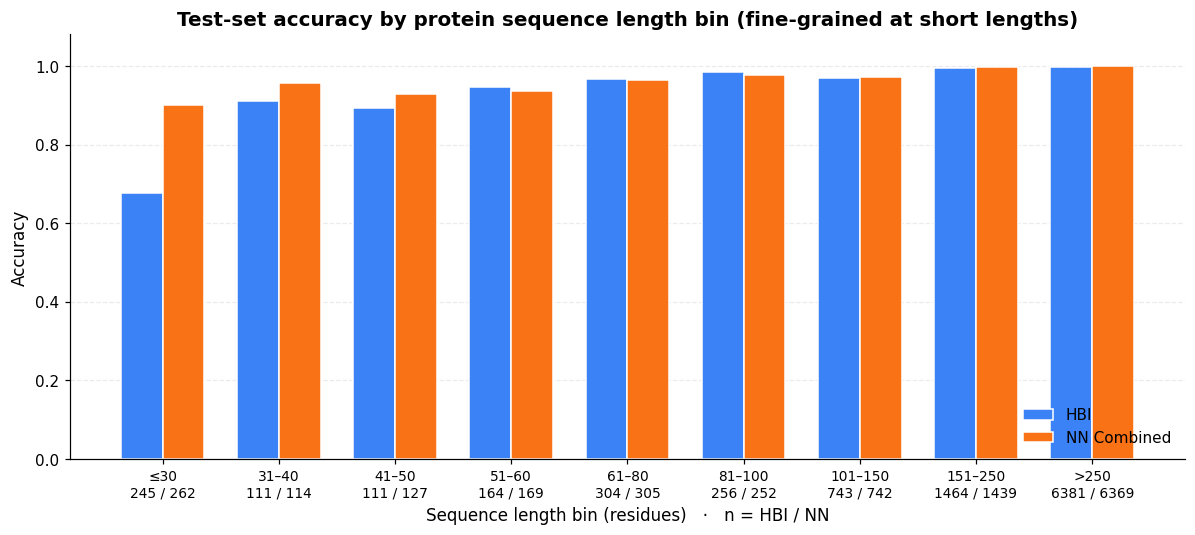

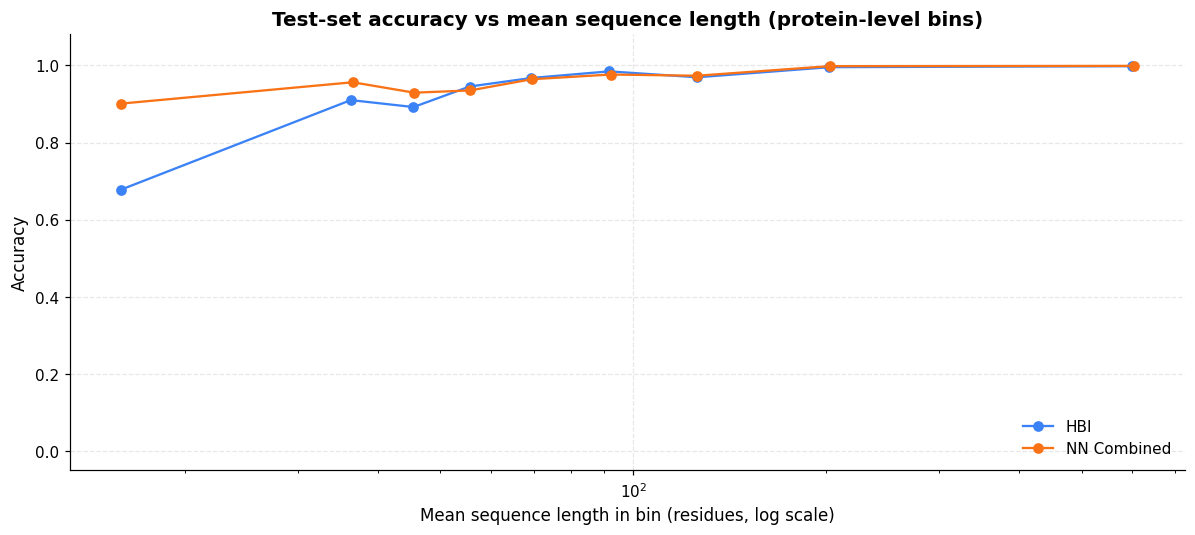

Spearman correlation (HBI, protein-level correct vs sequence length): +0.185
Spearman correlation (NN Combined, protein-level correct vs sequence length): +0.134


,length_bin,n_proteins,avg_seq_length,accuracy,method
0,≤30,245,15.873469,0.677551,HBI
1,31–40,111,36.261261,0.909910,HBI
2,41–50,111,45.414414,0.891892,HBI
3,51–60,164,55.567073,0.945122,HBI
4,61–80,304,69.250000,0.967105,HBI
5,81–100,256,91.710938,0.984375,HBI
6,101–150,743,125.790040,0.969044,HBI
7,151–250,1464,202.168716,0.995219,HBI
8,>250,6381,600.130701,0.997806,HBI
9,≤30,262,15.877863,0.900763,NN Combined


In [340]:
from pathlib import Path

hbi_preds = pd.read_csv("../benchmark/test_set/hbi/predictions.csv")
nn_preds = pd.read_csv("../benchmark/test_set/nn_combined_run/predictions.csv")

training_df = pd.read_csv("../data/processed/training_data.csv")
training_df["seq_length"] = training_df["Sequence"].str.len()
seq_lengths = training_df[["identifier", "seq_length"]]

# Fine resolution in the short-protein region (where the toxin families live and
# where the methods actually differ); the long nontox tail is collapsed into one bin.
length_bins = [0, 30, 40, 50, 60, 80, 100, 150, 250, np.inf]
length_labels = [
    "≤30",
    "31–40",
    "41–50",
    "51–60",
    "61–80",
    "81–100",
    "101–150",
    "151–250",
    ">250",
]


def protein_accuracy_by_length(preds: pd.DataFrame, method: str) -> pd.DataFrame:
    df = preds.assign(correct=preds["actual_label"] == preds["predicted_label"]).merge(
        seq_lengths, on="identifier", how="inner"
    )
    df["length_bin"] = pd.cut(
        df["seq_length"],
        bins=length_bins,
        labels=length_labels,
        right=True,
        include_lowest=True,
    )
    binned = (
        df.groupby("length_bin", observed=True)
        .agg(
            n_proteins=("identifier", "count"),
            avg_seq_length=("seq_length", "mean"),
            accuracy=("correct", "mean"),
        )
        .reset_index()
    )
    binned["method"] = method
    return df, binned


hbi_proteins, hbi_binned = protein_accuracy_by_length(hbi_preds, "HBI")
nn_proteins, nn_binned = protein_accuracy_by_length(nn_preds, "NN Combined")
binned_perf = pd.concat([hbi_binned, nn_binned], ignore_index=True)

x = np.arange(len(length_labels))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(
    x - width / 2,
    hbi_binned["accuracy"],
    width,
    label="HBI",
    color=HBI_COLOR,
    edgecolor="white",
)
ax.bar(
    x + width / 2,
    nn_binned["accuracy"],
    width,
    label="NN Combined",
    color=NN_COLOR,
    edgecolor="white",
)

# Compact two-line tick labels: bin on top, sample sizes (HBI / NN) below.
ax.set_xticks(x)
ax.set_xticklabels(
    [
        f"{label}\n{h_n} / {n_n}"
        for label, h_n, n_n in zip(
            length_labels,
            hbi_binned["n_proteins"],
            nn_binned["n_proteins"],
        )
    ],
    fontsize=9,
)
ax.set_ylim(0, 1.08)
ax.set_xlabel("Sequence length bin (residues)   ·   n = HBI / NN")
ax.set_ylabel("Accuracy")
ax.set_title("Test-set accuracy by protein sequence length bin (fine-grained at short lengths)")
ax.grid(axis="x", visible=False)
ax.legend(loc="lower right")
plt.tight_layout()
save_plot(fig, "test_set_accuracy_by_seq_length_bin_bars.png")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for method_df, color, label in [
    (hbi_binned, HBI_COLOR, "HBI"),
    (nn_binned, NN_COLOR, "NN Combined"),
]:
    ax.plot(
        method_df["avg_seq_length"],
        method_df["accuracy"],
        marker="o",
        color=color,
        label=label,
    )
ax.set_xscale("log")
ax.set_xlabel("Mean sequence length in bin (residues, log scale)")
ax.set_ylabel("Accuracy")
ax.set_title("Test-set accuracy vs mean sequence length (protein-level bins)")
ax.set_ylim(-0.05, 1.08)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
save_plot(fig, "test_set_accuracy_by_seq_length_bin_line.png")
plt.show()

for proteins, name in [(hbi_proteins, "HBI"), (nn_proteins, "NN Combined")]:
    corr = proteins[["seq_length", "correct"]].corr(method="spearman").iloc[0, 1]
    print(f"Spearman correlation ({name}, protein-level correct vs sequence length): {corr:+.3f}")

binned_perf

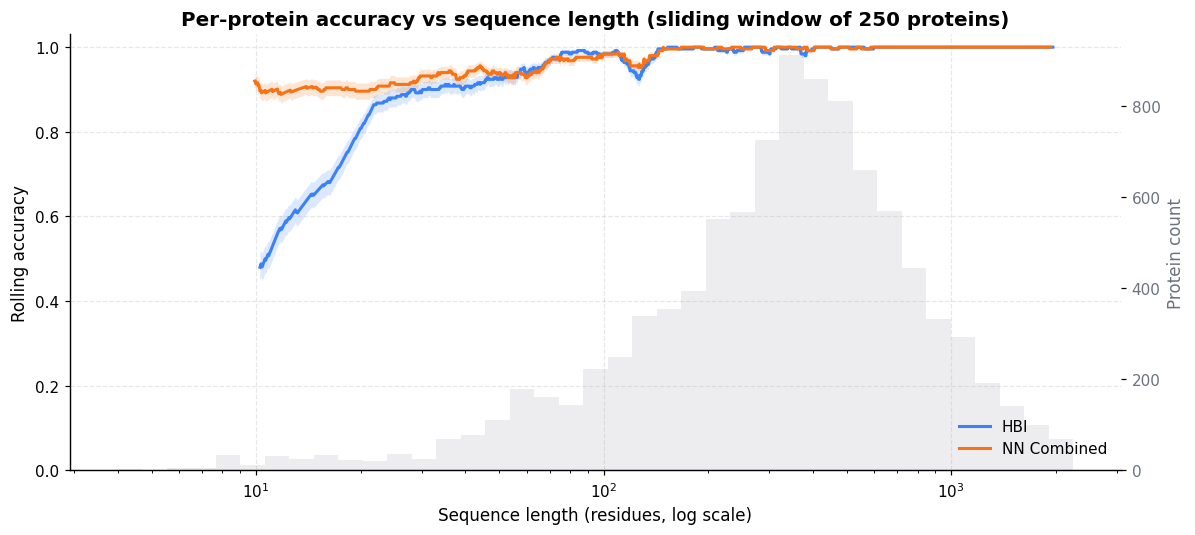

In [341]:
# ---------------------------------------------------------------------------
# Bin-free view of the same question: rolling accuracy vs sequence length.
# Proteins are sorted by length and accuracy is averaged over a sliding window,
# so there are no bin-edge artifacts. Shaded band = ±1 binomial SE of the
# window mean; the grey histogram shows where proteins actually lie.
# (reuses hbi_preds / nn_preds / seq_lengths from the cell above)
# ---------------------------------------------------------------------------
WINDOW = 250


def rolling_accuracy(preds: pd.DataFrame, window: int = WINDOW) -> pd.DataFrame:
    df = (
        preds.assign(correct=preds["actual_label"] == preds["predicted_label"])
        .merge(seq_lengths, on="identifier", how="inner")
        .sort_values("seq_length")
        .reset_index(drop=True)
    )
    acc = df["correct"].rolling(window, center=True, min_periods=window // 2).mean()
    df["roll_acc"] = acc
    df["roll_len"] = (
        df["seq_length"].rolling(window, center=True, min_periods=window // 2).mean()
    )
    df["roll_se"] = np.sqrt(acc * (1 - acc) / window)
    return df


hbi_roll = rolling_accuracy(hbi_preds)
nn_roll = rolling_accuracy(nn_preds)

fig, ax = plt.subplots(figsize=(11, 5))

# Background: protein length distribution (log-spaced bins) on a twin axis.
lengths = hbi_roll["seq_length"]
ax_hist = ax.twinx()
ax_hist.hist(
    lengths,
    bins=np.logspace(np.log10(lengths.min()), np.log10(lengths.max()), 40),
    color=NEUTRAL_COLOR,
    alpha=0.12,
)
ax_hist.set_ylabel("Protein count", color=NEUTRAL_COLOR)
ax_hist.tick_params(axis="y", labelcolor=NEUTRAL_COLOR)
ax_hist.grid(False)

for d, color, label in [(hbi_roll, HBI_COLOR, "HBI"), (nn_roll, NN_COLOR, "NN Combined")]:
    ax.plot(d["roll_len"], d["roll_acc"], color=color, lw=2, label=label, zorder=3)
    ax.fill_between(
        d["roll_len"],
        d["roll_acc"] - d["roll_se"],
        d["roll_acc"] + d["roll_se"],
        color=color,
        alpha=0.18,
        lw=0,
        zorder=2,
    )

# Keep the accuracy lines visually above the background histogram.
ax.set_zorder(ax_hist.get_zorder() + 1)
ax.patch.set_visible(False)
ax.set_xscale("log")
ax.set_xlabel("Sequence length (residues, log scale)")
ax.set_ylabel("Rolling accuracy")
ax.set_ylim(0, 1.03)
ax.set_title(
    f"Per-protein accuracy vs sequence length (sliding window of {WINDOW} proteins)"
)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
save_plot(fig, "test_set_accuracy_vs_seq_length_rolling.png")
plt.show()

## Average Sequence Length vs Performance per Family

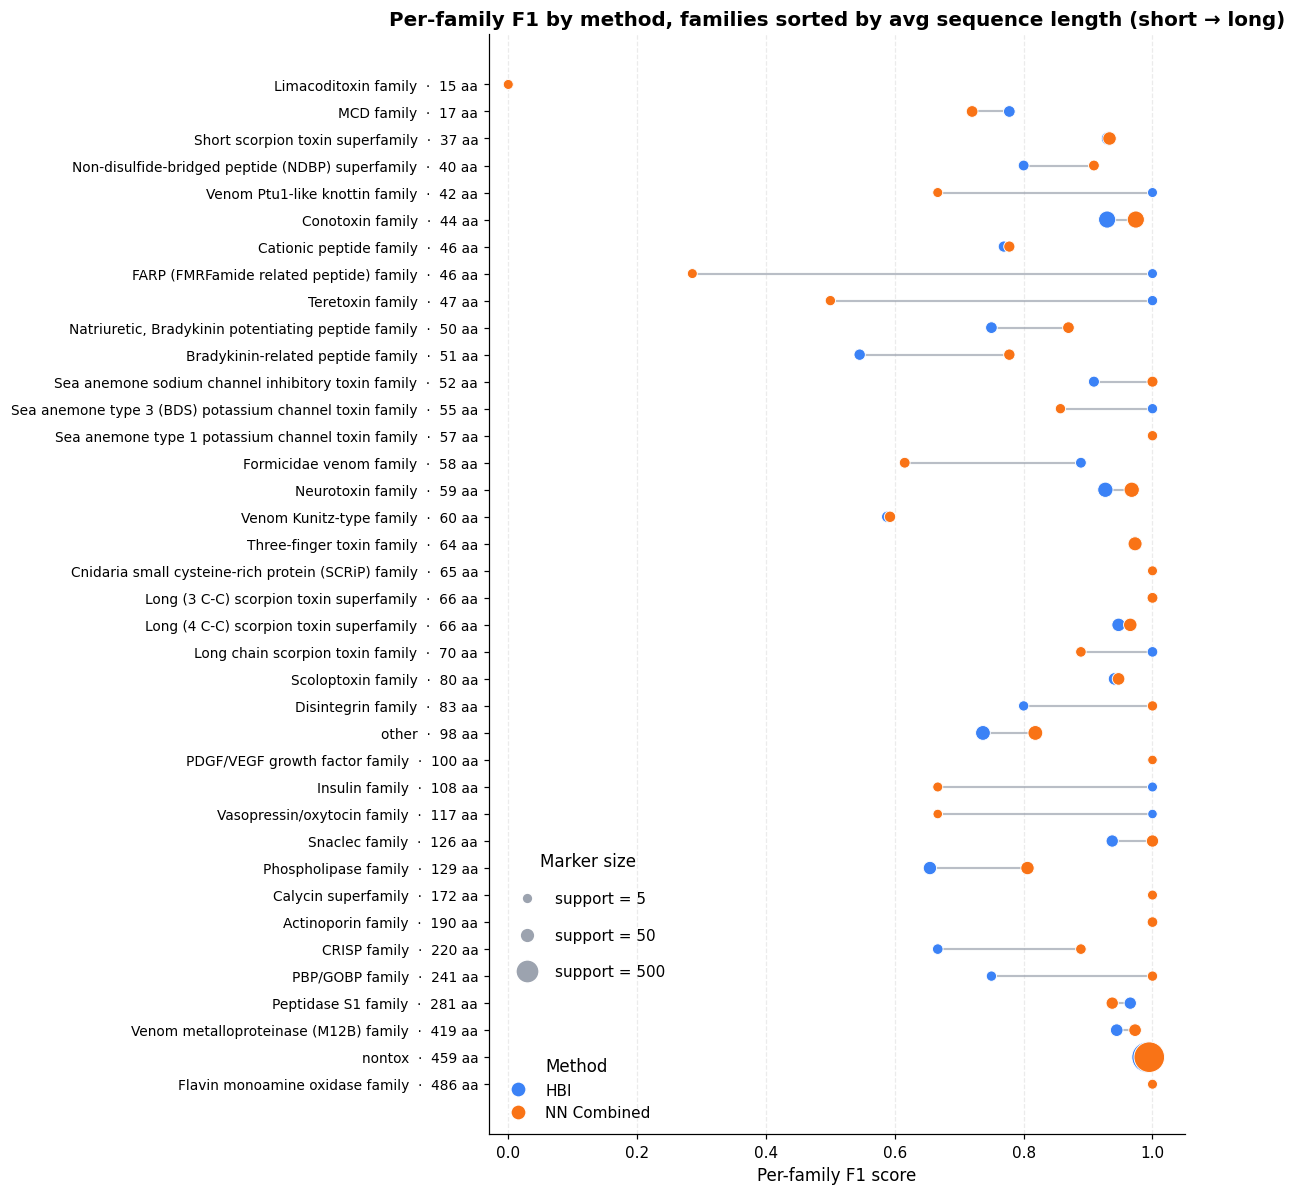

In [342]:
import json
from pathlib import Path

from matplotlib.lines import Line2D

family_training_df = pd.read_csv("../data/processed/training_data.csv")
family_training_df["seq_length"] = family_training_df["Sequence"].str.len()

test_df = family_training_df[family_training_df["Split"] == "test"]
family_lengths = (
    test_df.groupby("Protein families")["seq_length"]
    .agg(avg_seq_length="mean", median_seq_length="median", n_test="count")
)

with Path("../benchmark/test_set/hbi/metrics.json").open() as f:
    hbi_metrics = json.load(f)
with Path("../benchmark/test_set/nn_combined_run/metrics.json").open() as f:
    nn_metrics = json.load(f)

ignore = {"accuracy", "macro avg", "weighted avg", "micro avg"}


def family_f1_table(metrics: dict, method: str) -> pd.DataFrame:
    rows = []
    for family, vals in metrics["classification_report"].items():
        if family in ignore or not isinstance(vals, dict):
            continue
        rows.append(
            {
                "family": family,
                f"{method}_f1": vals["f1-score"],
                "support": int(vals["support"]),
            }
        )
    return pd.DataFrame(rows)


hbi_fam = family_f1_table(hbi_metrics, "hbi")
nn_fam = family_f1_table(nn_metrics, "nn").drop(columns=["support"])

family_perf = (
    hbi_fam.merge(nn_fam, on="family")
    .merge(family_lengths, left_on="family", right_index=True, how="left")
    .dropna(subset=["avg_seq_length"])
)

fam_sorted = family_perf.sort_values("avg_seq_length").reset_index(drop=True)
y = np.arange(len(fam_sorted))


def _scale_support(support):
    return np.clip(30 + np.sqrt(support) * 9, 30, 400)


sizes = _scale_support(fam_sorted["support"])

fig, ax = plt.subplots(figsize=(11, 11))

for i, row in fam_sorted.iterrows():
    ax.plot(
        [row["hbi_f1"], row["nn_f1"]],
        [i, i],
        color="#9ca3af",
        lw=1.4,
        alpha=0.7,
        zorder=1,
    )

ax.scatter(
    fam_sorted["hbi_f1"],
    y,
    s=sizes,
    color=HBI_COLOR,
    edgecolor="white",
    lw=0.6,
    zorder=3,
)
ax.scatter(
    fam_sorted["nn_f1"],
    y,
    s=sizes,
    color=NN_COLOR,
    edgecolor="white",
    lw=0.6,
    zorder=3,
)

ax.set_yticks(y)
ax.set_yticklabels(
    [
        f"{f}  ·  {int(round(l))} aa"
        for f, l in zip(fam_sorted["family"], fam_sorted["avg_seq_length"])
    ],
    fontsize=9,
)
ax.invert_yaxis()

ax.set_xlim(-0.03, 1.05)
ax.set_xlabel("Per-family F1 score")
ax.set_title("Per-family F1 by method, families sorted by avg sequence length (short → long)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.25)

method_legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=HBI_COLOR, markersize=10, label="HBI"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=NN_COLOR,
        markersize=10,
        label="NN Combined",
    ),
]
ref_supports = [5, 50, 500]
size_legend = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#9ca3af",
        markeredgecolor="white",
        markersize=np.sqrt(_scale_support(s)),
        label=f"support = {s}",
    )
    for s in ref_supports
]

leg1 = ax.legend(handles=method_legend, loc="lower left", title="Method")
ax.add_artist(leg1)
ax.legend(
    handles=size_legend,
    loc="lower left",
    bbox_to_anchor=(0.0, 0.12),
    title="Marker size",
    labelspacing=1.4,
    borderpad=1.0,
)

plt.tight_layout()
save_plot(fig, "test_set_family_f1_dumbbell_by_seq_length.png")
plt.show()


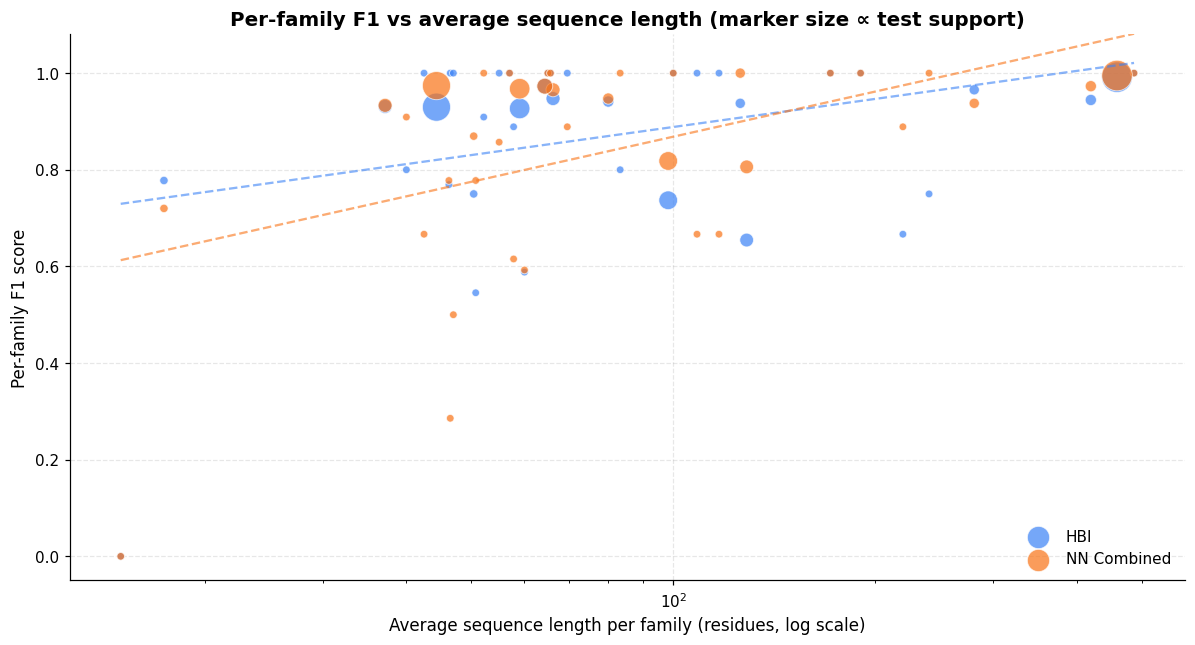

Spearman correlation with avg sequence length:
  HBI:         +0.210
  NN Combined: +0.469


,family,avg_seq_length,median_seq_length,n_test,support,hbi_f1,nn_f1
0,Limacoditoxin family,15.000000,15.0,2,2,0.000000,0.000000
1,MCD family,17.400000,14.0,10,10,0.777778,0.720000
2,Short scorpion toxin superfamily,37.178571,37.0,28,28,0.931034,0.933333
3,Non-disulfide-bridged peptide (NDBP) superfamily,40.000000,39.0,5,5,0.800000,0.909091
4,Venom Ptu1-like knottin family,42.500000,42.5,2,2,1.000000,0.666667
5,Conotoxin family,44.353982,46.0,113,113,0.929577,0.974138
6,Cationic peptide family,46.285714,37.0,7,7,0.769231,0.777778
7,FARP (FMRFamide related peptide) family,46.500000,46.5,2,2,1.000000,0.285714
8,Teretoxin family,47.000000,47.0,3,3,1.000000,0.500000
9,"Natriuretic, Bradykinin potentiating peptide f...",50.400000,12.5,10,10,0.750000,0.869565


In [343]:
fig, ax = plt.subplots(figsize=(11, 6))

scatter_sizes = np.clip(family_perf["support"] * 3, 25, 400)

ax.scatter(
    family_perf["avg_seq_length"],
    family_perf["hbi_f1"],
    s=scatter_sizes,
    alpha=0.7,
    color=HBI_COLOR,
    edgecolor="white",
    lw=0.6,
    label="HBI",
)
ax.scatter(
    family_perf["avg_seq_length"],
    family_perf["nn_f1"],
    s=scatter_sizes,
    alpha=0.7,
    color=NN_COLOR,
    edgecolor="white",
    lw=0.6,
    label="NN Combined",
)

for method, color in [("hbi_f1", HBI_COLOR), ("nn_f1", NN_COLOR)]:
    xv = family_perf["avg_seq_length"].values
    yv = family_perf[method].values
    if len(xv) >= 2:
        slope, intercept = np.polyfit(np.log10(xv), yv, 1)
        xs = np.logspace(np.log10(xv.min()), np.log10(xv.max()), 100)
        ax.plot(xs, slope * np.log10(xs) + intercept, color=color, linestyle="--", alpha=0.6)

ax.set_xscale("log")
ax.set_xlabel("Average sequence length per family (residues, log scale)")
ax.set_ylabel("Per-family F1 score")
ax.set_title("Per-family F1 vs average sequence length (marker size ∝ test support)")
ax.set_ylim(-0.05, 1.08)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
save_plot(fig, "test_set_family_f1_vs_seq_length_scatter.png")
plt.show()

corr = family_perf[["avg_seq_length", "hbi_f1", "nn_f1"]].corr(method="spearman")
print("Spearman correlation with avg sequence length:")
print(f"  HBI:         {corr.loc['hbi_f1', 'avg_seq_length']:+.3f}")
print(f"  NN Combined: {corr.loc['nn_f1', 'avg_seq_length']:+.3f}")

fam_sorted[
    ["family", "avg_seq_length", "median_seq_length", "n_test", "support", "hbi_f1", "nn_f1"]
]